In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
data = pd.read_csv("dataset_part_2.csv")

In [3]:
X = pd.read_csv("dataset_part_3.csv")

In [5]:
X

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6123.547647,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15600.000000,2.0,1.0,1.0,1.0,5.0,12.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
86,87.0,15600.000000,3.0,1.0,1.0,1.0,5.0,13.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
87,88.0,15600.000000,6.0,1.0,1.0,1.0,5.0,12.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
88,89.0,15600.000000,3.0,1.0,1.0,1.0,5.0,12.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [4]:
Y = data['Class'].to_numpy()

In [9]:
Y.shape

(90,)

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [6]:
transform = preprocessing.StandardScaler()

In [7]:
X_train = transform.fit_transform(X_train) 
X_test = transform.transform(X_test)    

In [8]:
Y_train.shape

(72,)

In [9]:
def plot_confusion_matrix(y,y_predict):
    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

### Logistic Regression

In [17]:
parameters = {"C":[0.01, 0.1, 1], 'penalty':['l2'], 'solver':['lbfgs']}

In [18]:
lr = LogisticRegression()

In [19]:
logreg_cv = GridSearchCV(estimator=lr, param_grid=parameters, cv=10)

In [20]:
logreg_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1], 'penalty': ['l2'],
                         'solver': ['lbfgs']})

In [21]:
print("tuned hyperparameters:", logreg_cv.best_params_)
print("validation accuracy:", logreg_cv.best_score_)

tuned hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
validation accuracy: 0.8214285714285714


In [22]:
test_accuracy = logreg_cv.score(X_test, Y_test)
print("test accuracy:", test_accuracy)

test accuracy: 0.8333333333333334


In [23]:
y_pred = logreg_cv.predict(X_test)

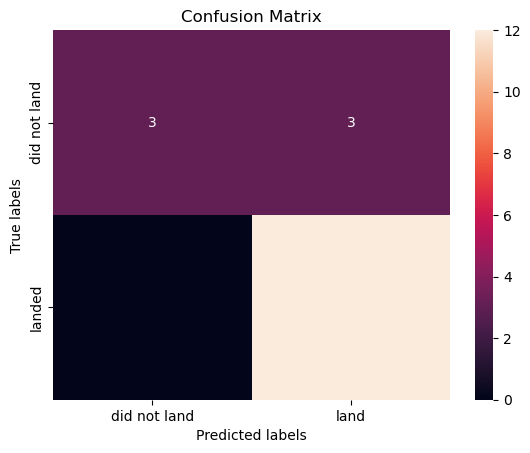

In [25]:
plot_confusion_matrix(Y_test,y_pred)

In [27]:
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[ 3  3]
 [ 0 12]]


### SVM, Decision Tree, KNN


 Model: SVM
Best Parameters: {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
Validation Accuracy: 0.85
Test Accuracy: 0.8333333333333334


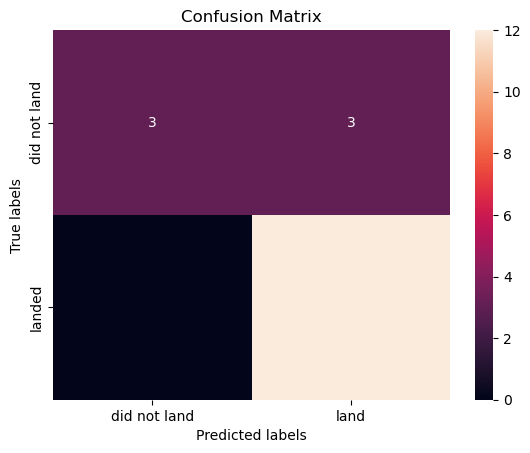

[[ 3  3]
 [ 0 12]]

 Model: Decision Tree


C:\Users\balaj\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'random'}
Validation Accuracy: 0.8625
Test Accuracy: 0.7777777777777778


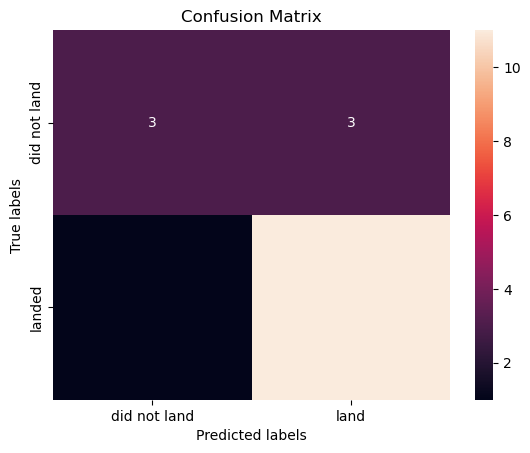

[[ 3  3]
 [ 1 11]]

 Model: KNN
Best Parameters: {'algorithm': 'auto', 'n_neighbors': 8, 'p': 1}
Validation Accuracy: 0.8464285714285713
Test Accuracy: 0.8333333333333334


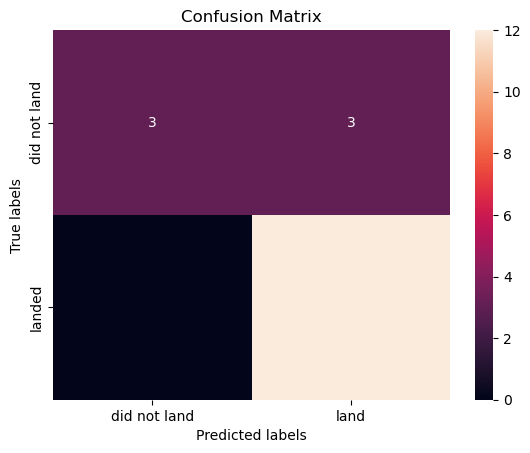

[[ 3  3]
 [ 0 12]]


In [10]:
models = {
    "SVM": (
        SVC(),
        {'kernel':('linear','rbf','poly','sigmoid'),
         'C': np.logspace(-3, 3, 5),
         'gamma': np.logspace(-3, 3, 5)}
    ),
    
    "Decision Tree": (
        DecisionTreeClassifier(),
        {'criterion': ['gini', 'entropy'],
         'splitter': ['best', 'random'],
         'max_depth': [2*n for n in range(1,10)],
         'max_features': ['sqrt'],
         'min_samples_leaf': [1, 2, 4],
         'min_samples_split': [2, 5, 10]}
    ),
    
    "KNN": (
        KNeighborsClassifier(),
        {'n_neighbors': [1,2,3,4,5,6,7,8,9,10],
         'algorithm': ['auto','ball_tree','kd_tree','brute'],
         'p': [1,2]}
    )
}

for name, (model, params) in models.items():
    
    print(f"\n Model: {name}")
    
    grid = GridSearchCV(estimator=model, param_grid=params, cv=10)
    
    grid.fit(X_train, Y_train)
    
    print("Best Parameters:", grid.best_params_)
    print("Validation Accuracy:", grid.best_score_)
    
    test_acc = grid.score(X_test, Y_test)
    print("Test Accuracy:", test_acc)
    
    y_pred = grid.predict(X_test)
    
    plot_confusion_matrix(Y_test, y_pred)
    cm = confusion_matrix(Y_test, y_pred)
    print(cm)